In [1]:
import cafe

cafe.logger.setLevel("DEBUG")
cafe.settings.backend = "conda"
# cafe.settings.

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Gastrulation/erythroid_lineage.h5ad'...                                                                                                          
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'celltype' in '.obs' columns as 'cluster' key                                                                                                                               

array([[<Axes: title={'center': 'ref(celltype)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

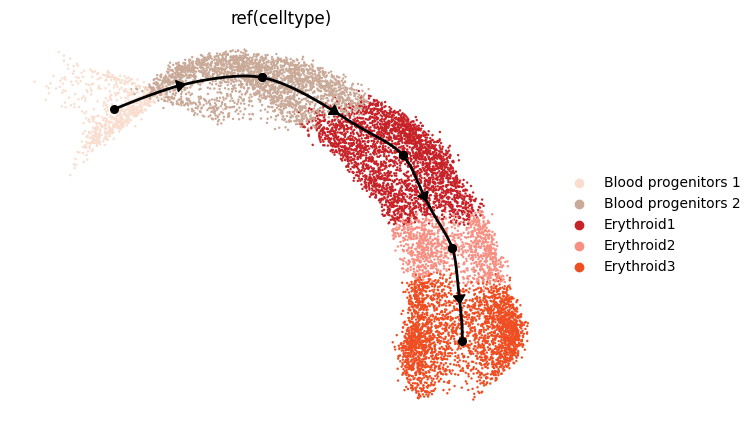

In [2]:
fadata = cafe.data.read_erythroid_lineage()
# cafe.plot.plot_embedding_plotly(fadata) # interactive plotly plot and mannually 
cafe.plot.plot_trajectory(fadata)

In [4]:
method2parameters = {
    # "scvelo": {},
    # "dynamo": {},
    # "palantir": {},
    # "cytotrace2": {
    #     "max_cores": 8,        # 减少并行核心数，降低内存使用
    #     "batch_size": 1024,    # 减小批处理大小
    # },
    # "veloae": {},
    "pyrovelocity": {
        "configuration_kwargs": {
            "training_configuration_1":{
                "batch_size": 1024,  # 减小批处理大小
                "max_epochs": 50,    # 减少训练轮数
            }
        }
    }, # TODO: 这里传参要优化一下
    # "stavia": {},
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = True # use common preprocessing
    parameters["benchmark_resource"] = True # record resource usage
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)

DEBUG    |- load conda backend                                                                                                                                                                          
DEBUG    |--- Conda environment 'pyrovelocity' is available: Python 3.11.13                                                                                                                             
DEBUG    |- Loaded function 'pyrovelocity': <function pyrovelocity at 0x72c47b5c2c20>                                                                                                                   
INFO     |- method backend loaded: CondaBackend: pyrovelocity in conda env 'pyrovelocity'                                                                                                               
DEBUG    |- set new log file: .cafe/erythroid_lineage/log/20251203_151556__pyrovelocity-conda__Xpvd1FYFLI.log                                                                                       

TypeError: 'NoneType' object is not subscriptable

DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- plot_trajectory for model_name:'20251202_171924__cytotrace2-conda__AySPHzhqdD', color:'celltype'                                                                                            
DEBUG    |- plot_trajectory for model_name:'20251202_171924__cytotrace2-conda__AySPHzhqdD', color:'celltype'                                                                                            
DEBUG    |- plot_trajectory for model_name:'20251202_171924__cytotrace2-conda__AySPHzhqdD', color:'milestone'                                                                                           
DEBUG    |- plot_trajectory for model_name:'20251202_171924__cytotrace2-conda__AySPHzhqdD', color:'milestone'                                                                                       

array([[<Axes: title={'center': 'cytotrace2-conda(celltype)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'veloae-conda(celltype)'}, xlabel='X_umap1', ylabel='X_umap2'>],
       [<Axes: title={'center': 'cytotrace2-conda(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>,
        <Axes: title={'center': 'veloae-conda(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>]],
      dtype=object)

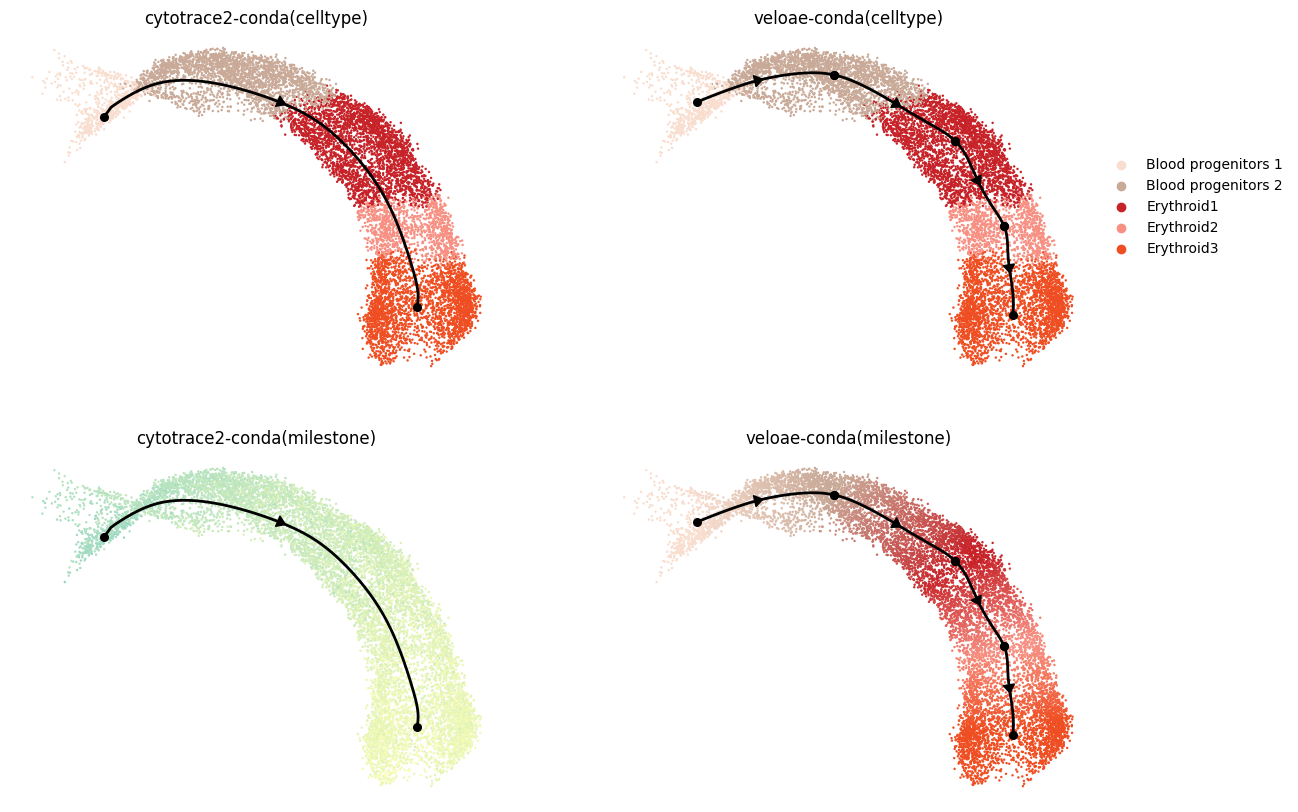

In [ ]:
model_name_list = fadata.get_all_model_name(parse=False)
model_name_list.remove("ref")  # remove ref trajectory
color_list = ["celltype", "milestone"]

cafe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [ ]:
fadata.write_trajectory_dict()

DEBUG    |- write trajectory 'ref' to '.cafe/erythroid_lineage/trajectory_history/ref.pkl'                                                                                                              
DEBUG    |- write trajectory '20251202_171924__cytotrace2-conda__AySPHzhqdD' to '.cafe/erythroid_lineage/trajectory_history/20251202_171924__cytotrace2-conda__AySPHzhqdD.pkl'                          
DEBUG    |- write trajectory '20251202_171924__cytotrace2-conda__AySPHzhqdD' to '.cafe/erythroid_lineage/trajectory_history/20251202_171924__cytotrace2-conda__AySPHzhqdD.pkl'                          
